In [ ]:
# Import pustaka yang diperlukan
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow
import time

In [ ]:
# Fungsi untuk menghitung Photo Severity Index (PSI) dan Damage Category
def calculate_psi_and_category(image_path):
    # Mulai pengukuran waktu
    start_time = time.time()

    # Langkah 1: Baca gambar
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Gambar tidak ditemukan atau tidak bisa dibaca!")

    # Langkah 2: Pre-processing - Konversi ke grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Konversi ke RGB untuk visualisasi
    gray = cv2.cvtColor(gray, cv2.COLOR_RGB2GRAY)  # Konversi ke grayscale

    # Langkah 3: Pre-processing - Thresholding adaptif
    binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY_INV, 11, 2)

    # Langkah 4: Segmentasi - Deteksi kontur
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Filter kontur untuk menghilangkan noise
    valid_contours = [c for c in contours if cv2.contourArea(c) > 100]
    total_contour_area = sum(cv2.contourArea(c) for c in valid_contours)

    # Hitung persentase kerusakan
    height, width = gray.shape
    total_area = height * width
    damage_percentage = (total_contour_area / total_area) * 100

    # Langkah 5: Tentukan PSI dan Damage Category berdasarkan rubrik kustom
    if damage_percentage <= 20:
        psi_index = 0
        damage_category = "Minimal damage"
    elif damage_percentage <= 40:
        psi_index = 1
        damage_category = "Light damage"
    elif damage_percentage <= 60:
        psi_index = 2
        damage_category = "Moderate damage"
    elif damage_percentage <= 80:
        psi_index = 3
        damage_category = "Severe damage"
    else:
        psi_index = 4
        damage_category = "Very severe damage"

    # Langkah 6: Visualisasi
    image_with_roi = image.copy()
    for contour in valid_contours:
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(image_with_roi, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Kotak hijau

    mask = np.zeros_like(image)
    cv2.drawContours(mask, valid_contours, -1, (0, 0, 255), -1)  # Mask merah
    image_with_mask = cv2.addWeighted(image, 0.8, mask, 0.2, 0)

    # Tampilkan hasil
    cv2_imshow(image)  # Gambar asli
    print("Original Image")

    cv2_imshow(image_with_roi)  # Gambar dengan ROI
    print(f"Image with ROI")

    cv2_imshow(image_with_mask)  # Gambar dengan mask
    print(f"Image with Mask")

    # Output hasil
    print("\nAnalysis Results:")
    print(f"Damage Percentage: {damage_percentage:.2f}%")
    print(f"PSI Index: {psi_index}")
    print(f"Damage Category: {damage_category}")

    # Akhiri pengukuran waktu dan hitung runtime
    end_time = time.time()
    runtime = end_time - start_time
    print(f"Runtime: {runtime:.2f} seconds")

    return damage_percentage, psi_index, damage_category, runtime

In [ ]:
# Langkah 7: Koleksi data dan eksekusi
print("Please upload an image of the hospital for analysis:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

Please upload an image of the hospital for analysis:


Saving 00000002.jpg to 00000002.jpg


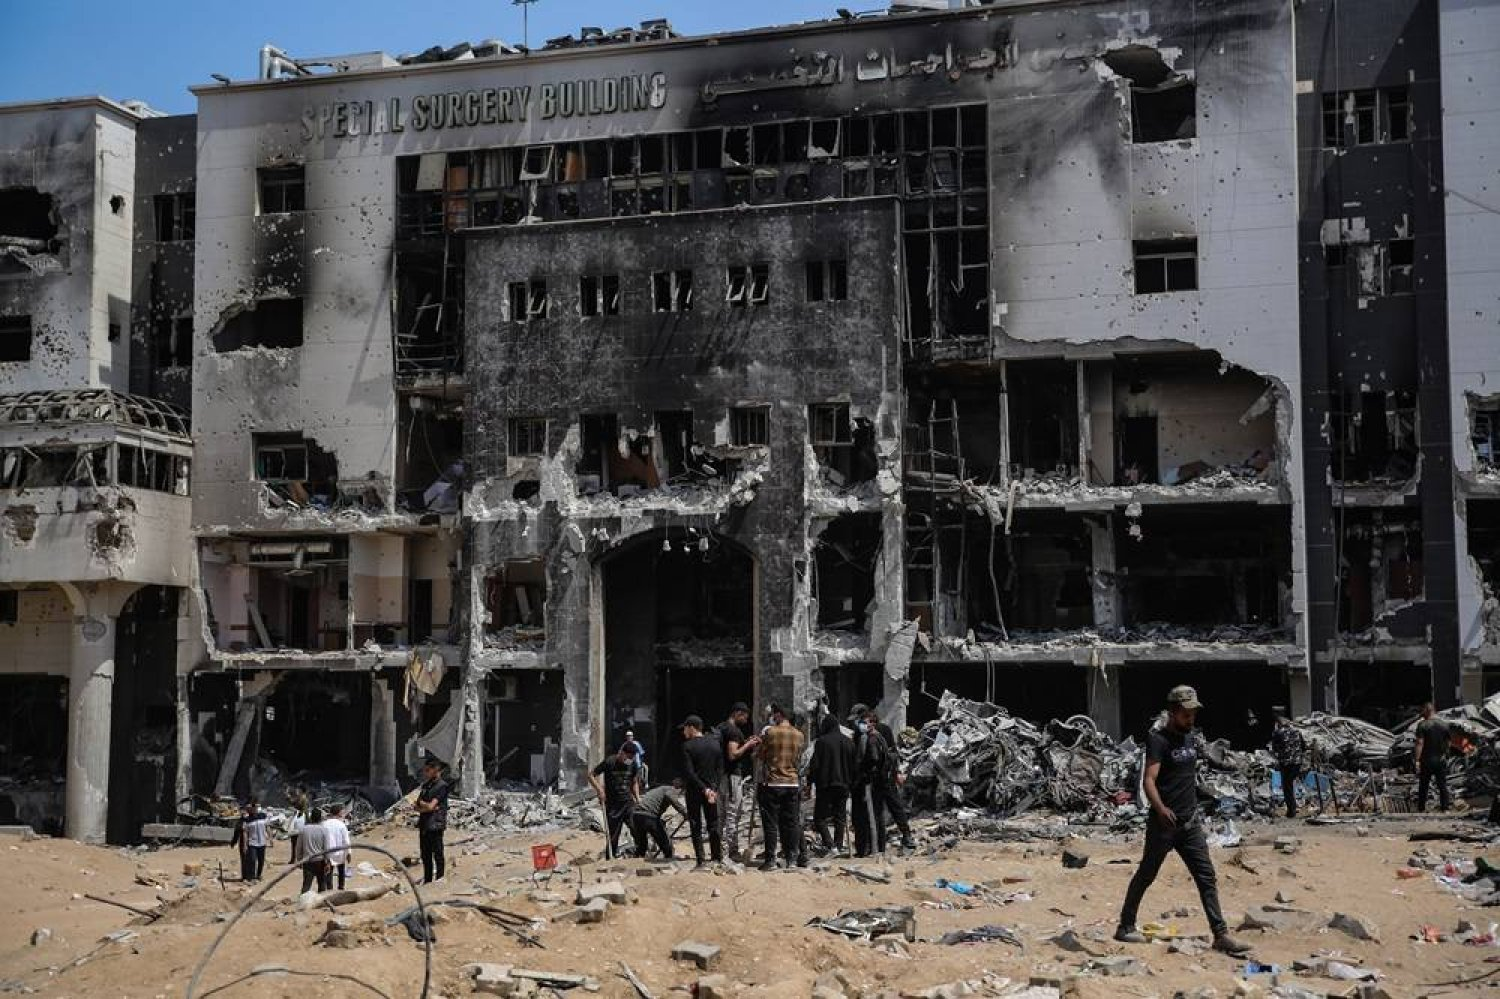

Original Image


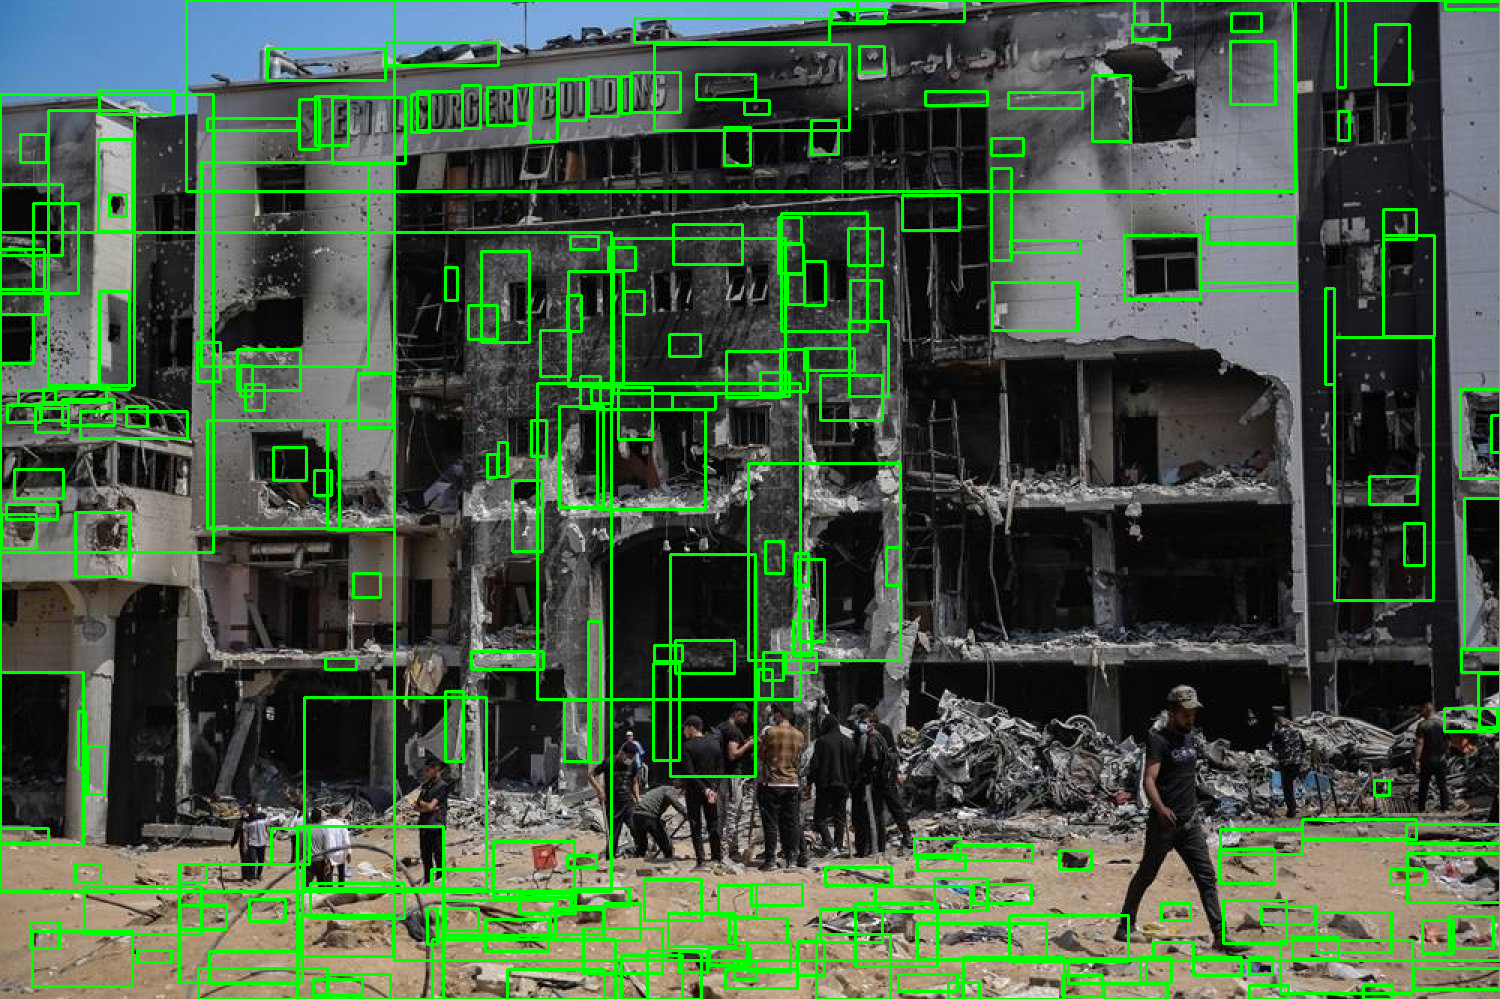

Image with ROI


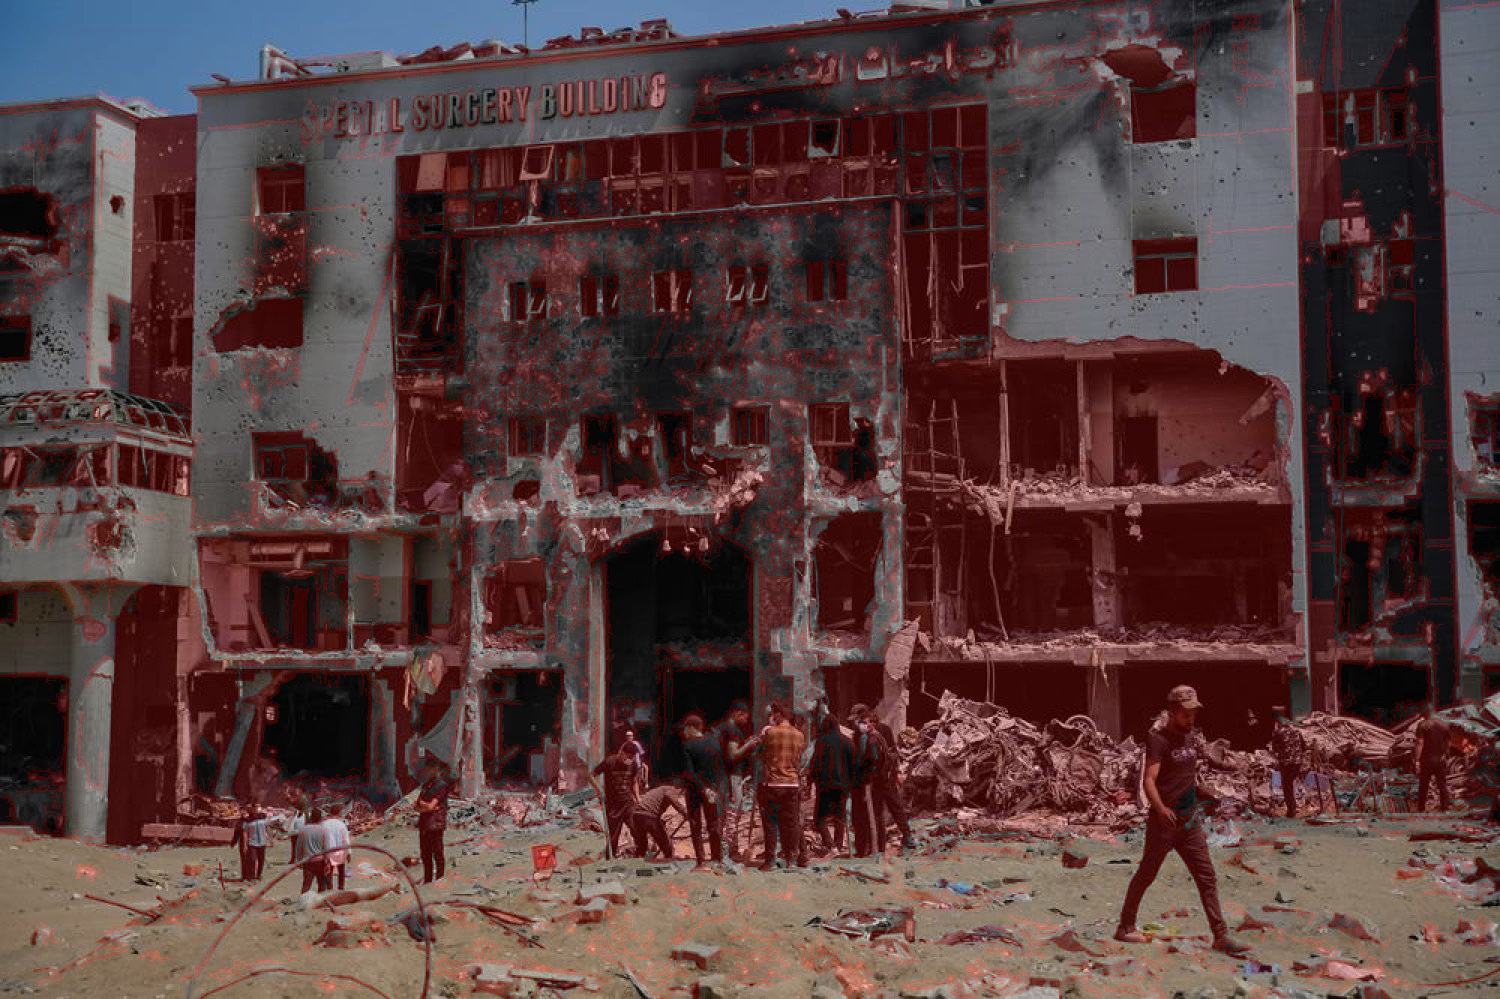

Image with Mask

Analysis Results:
Damage Percentage: 40.27%
PSI Index: 2
Damage Category: Moderate damage
Runtime: 1.14 seconds
Error: too many values to unpack (expected 3)


In [ ]:
# Eksekusi fungsi
try:
    damage_percentage, psi_index, damage_category = calculate_psi_and_category(image_path)
except ValueError as e:
    print(f"Error: {e}")